# Tissue-resolved single-cell expression of a query gene in T cells (NSCLC, GSE99254)

**Reproducible analysis notebook.** Tests whether a query gene is upregulated in
**tumor-infiltrating** T cells versus **peripheral blood** and **adjacent normal**
tissue, using the T-cell scRNA-seq atlas of non-small-cell lung cancer.

- **Dataset:** [GSE99254](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE99254) — Guo *et al.*, *Nature Medicine* (2018).
  FACS-sorted T cells, SMART-seq2, from tumor / adjacent-normal / peripheral blood of 14 treatment-naïve NSCLC patients.
- **Query gene (default):** `PDCD1` (PD-1) — change the `GENE` parameter in the config cell to re-run for any gene.
- **Outputs:** a two-panel figure and two CSV tables written to `results/`.

The cell-name prefix encodes tissue and subtype, e.g. `TTC5-0616A`:
`T`=Tumor / `N`=Normal / `P`=Peripheral, then `TC`=CD8, `TH`=CD4-helper, `TR`=Treg, `TY`=CD4-other, `TS`=CD8-other.

## 1. Configuration (parameters)

In [1]:
# ---- Parameters: edit GENE to analyze a different gene ----
GENE = "PDCD1"          # query gene symbol (PDCD1 = PD-1)

GEO_ACCESSION = "GSE99254"
TPM_URL = ("https://ftp.ncbi.nlm.nih.gov/geo/series/GSE99nnn/"
           "GSE99254/suppl/GSE99254_NSCLC.TCell.S12346.TPM.txt.gz")
DATA_DIR = "data"
RESULTS_DIR = "results"
TPM_PATH = f"{DATA_DIR}/GSE99254_TPM.txt.gz"

## 2. Environment

In [2]:
import os, re, urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 8, "axes.titlesize": 8.5, "axes.labelsize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "font.family": "DejaVu Sans",
})
META_GREY = "#7f7f7f"
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.3 | numpy 2.4.6


## 3. Download the processed TPM matrix from GEO
Downloaded once and cached in `data/`.

In [3]:
if not os.path.exists(TPM_PATH):
    print("Downloading TPM matrix (~330 MB) ...")
    urllib.request.urlretrieve(TPM_URL, TPM_PATH)
    print("done")
else:
    print("Using cached", TPM_PATH)
print("size (MB):", round(os.path.getsize(TPM_PATH)/1e6, 1))

Using cached data/GSE99254_TPM.txt.gz
size (MB): 342.6


## 4. Extract the query gene (memory-efficient)
The matrix is 23k genes x 12k cells (~330 MB gzip). Instead of loading it all, we stream the file and keep only the **header** and the **single query-gene row** — a few MB of RAM, so this runs on a laptop.

In [4]:
import gzip

header = None
gene_line = None
with gzip.open(TPM_PATH, "rt") as fh:
    header = fh.readline().rstrip("\n").split("\t")
    for line in fh:
        # symbol is the 2nd tab-delimited field; cheap prefix test before full split
        first_tab = line.find("\t")
        second_tab = line.find("\t", first_tab + 1)
        symbol = line[first_tab + 1:second_tab]
        if symbol == GENE:
            gene_line = line.rstrip("\n").split("\t")
            break

assert gene_line is not None, f"{GENE} not found in matrix"
cell_cols = header[2:]
expr = pd.Series(np.array(gene_line[2:], dtype=float), index=cell_cols)
print(f"{GENE} found (geneID={gene_line[0]}) across {len(cell_cols)} cells")

PDCD1 found (geneID=5133) across 12346 cells


## 5. Decode tissue origin & T-cell subtype from cell names

In [5]:
TISSUE = {"N": "Normal", "P": "Peripheral", "T": "Tumor"}
SUBTYPE = {"C": "CD8", "H": "CD4_Th", "R": "Treg", "Y": "CD4_other", "S": "CD8_other"}

def parse(cell):
    m = re.match(r"^([NPT])T([CHRYS])", cell)
    if not m:
        return (None, None)
    return TISSUE[m.group(1)], SUBTYPE[m.group(2)]

meta = pd.DataFrame({"cell": cell_cols})
meta[["tissue", "subtype"]] = pd.DataFrame([parse(c) for c in cell_cols], index=meta.index)
meta["TPM"] = expr.values
meta["log2"] = np.log2(meta["TPM"] / 10 + 1)

m = meta.dropna(subset=["tissue"]).copy()
print(f"labeled T cells: {len(m)} / {len(meta)}")
print(pd.crosstab(m["tissue"], m["subtype"]))

labeled T cells: 12210 / 12346
subtype     CD4_Th  CD4_other   CD8  CD8_other  Treg
tissue                                              
Normal         655        238   934        139   149
Peripheral    1254        672  1323        162   849
Tumor         1591        892  2182         70  1100


## 6. Statistics
Cell-level Mann-Whitney U (two-sided) on `log2(TPM/10+1)`: Tumor vs Blood and Tumor vs Normal, overall and within each subtype.

> *Note:* the numeric suffix in cell names is a within-group serial, **not** a stable patient ID, so a patient-paired pseudobulk test cannot be built from this file alone. Tests below are cell-level.

In [6]:
ORDER = ["Peripheral", "Normal", "Tumor"]
LABEL = {"Peripheral": "Blood", "Normal": "Normal", "Tumor": "Tumor"}
SUBS = ["CD8", "CD4_Th", "Treg", "CD4_other"]
SUBLAB = {"CD8": "CD8", "CD4_Th": "CD4 helper", "Treg": "Treg", "CD4_other": "CD4 other"}

def mw(a, b):
    if len(a) < 3 or len(b) < 3:
        return np.nan
    return mannwhitneyu(a, b, alternative="two-sided")[1]

summ_rows = []
for comp, sel in [("All T cells", m)] + [(SUBLAB[s], m[m.subtype == s]) for s in SUBS]:
    for t in ORDER:
        v = sel[sel.tissue == t]
        summ_rows.append([comp, LABEL[t], len(v), round(v["log2"].mean(), 3),
                          round(v["log2"].median(), 3), round((v["TPM"] > 0).mean() * 100, 1)])
summary = pd.DataFrame(summ_rows, columns=["Compartment", "Tissue", "n_cells",
                                           "mean_log2", "median_log2", "pct_expressing"])

sig_rows = []
for comp, sel in [("All T cells", m)] + [(SUBLAB[s], m[m.subtype == s]) for s in SUBS]:
    T = sel[sel.tissue == "Tumor"]["log2"]; P = sel[sel.tissue == "Peripheral"]["log2"]; N = sel[sel.tissue == "Normal"]["log2"]
    sig_rows.append([comp, mw(T, P), mw(T, N)])
pvals = pd.DataFrame(sig_rows, columns=["Compartment", "p_Tumor_vs_Blood", "p_Tumor_vs_Normal"])

summary.to_csv(f"{RESULTS_DIR}/{GENE}_{GEO_ACCESSION}_summary.csv", index=False)
pvals.to_csv(f"{RESULTS_DIR}/{GENE}_{GEO_ACCESSION}_pvalues.csv", index=False)
display(summary)
display(pvals.assign(p_Tumor_vs_Blood=lambda d: d.p_Tumor_vs_Blood.map("{:.2e}".format),
                     p_Tumor_vs_Normal=lambda d: d.p_Tumor_vs_Normal.map("{:.2e}".format)))

    Compartment  Tissue  n_cells  mean_log2  median_log2  pct_expressing
0   All T cells   Blood     4260      0.427        0.000            16.9
1   All T cells  Normal     2115      1.088        0.000            32.5
2   All T cells   Tumor     5835      1.957        0.120            50.2
3           CD8   Blood     1323      0.480        0.000            17.8
4           CD8  Normal      934      1.055        0.000            35.1
5           CD8   Tumor     2182      2.137        0.177            53.1
6    CD4 helper   Blood     1254      0.445        0.000            17.6
7    CD4 helper  Normal      655      1.199        0.000            34.2
8    CD4 helper   Tumor     1591      1.938        0.000            46.6
9          Treg   Blood      849      0.346        0.000            16.6
10         Treg  Normal      149      1.486        0.000            34.9
11         Treg   Tumor     1100      1.671        0.140            50.8
12    CD4 other   Blood      672      0.382        

## 7. Figure

saved results/PDCD1_GSE99254.png


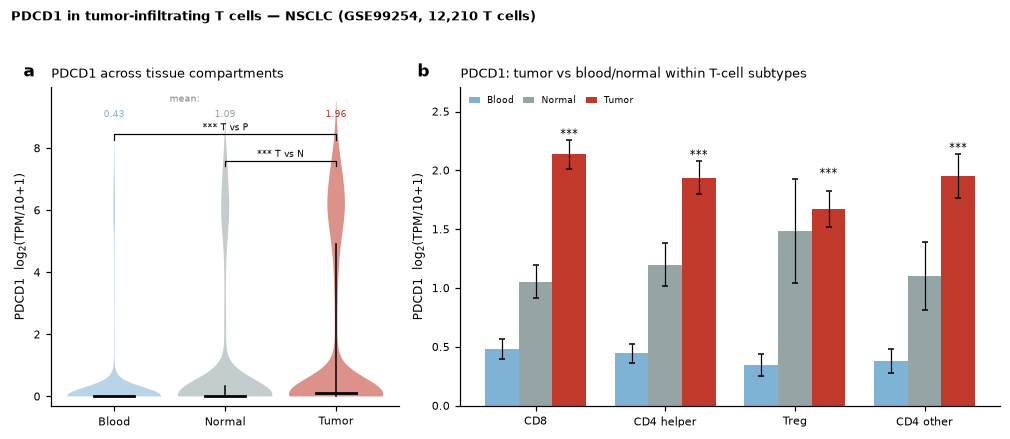

In [7]:
def stars(p):
    if p is None or np.isnan(p): return "n/a"
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 5e-2 else "ns"

colors = {"Peripheral": "#7fb3d5", "Normal": "#95a5a6", "Tumor": "#c0392b"}
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.0), gridspec_kw={"width_ratios": [1, 1.55]})

ax = axes[0]
data = [m[m.tissue == t]["log2"].values for t in ORDER]
parts = ax.violinplot(data, positions=range(3), showextrema=False, widths=0.85)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(colors[ORDER[i]]); pc.set_alpha(0.55); pc.set_edgecolor("none")
ymax = max(v.max() for v in data)
for i, t in enumerate(ORDER):
    v = m[m.tissue == t]["log2"]; q1, med, q3 = v.quantile([.25, .5, .75])
    ax.plot([i - .18, i + .18], [med, med], color="k", lw=1.8, zorder=5)
    ax.plot([i, i], [q1, q3], color="k", lw=1.0, zorder=4)
    ax.text(i, ymax * 0.94, f"{v.mean():.2f}", ha="center", va="bottom", fontsize=6, color=colors[t])
ax.set_xticks(range(3)); ax.set_xticklabels([LABEL[t] for t in ORDER])
ax.set_ylabel(f"{GENE}  log$_2$(TPM/10+1)"); ax.set_ylim(-0.3, ymax * 1.05)
ax.text(0.5, ymax * 1.0, "mean:", fontsize=6, color=META_GREY)
ax.set_title(f"{GENE} across tissue compartments")
pAP = mw(m[m.tissue=="Tumor"]["log2"], m[m.tissue=="Peripheral"]["log2"])
pAN = mw(m[m.tissue=="Tumor"]["log2"], m[m.tissue=="Normal"]["log2"])
def brack(ax, x1, x2, y, txt):
    ax.plot([x1, x1, x2, x2], [y, y+ymax*0.02, y+ymax*0.02, y], color="k", lw=0.8)
    ax.text((x1+x2)/2, y+ymax*0.025, txt, ha="center", va="bottom", fontsize=6)
brack(ax, 1, 2, ymax*0.78, f"{stars(pAN)} T vs N")
brack(ax, 0, 2, ymax*0.87, f"{stars(pAP)} T vs P")

ax = axes[1]
x = np.arange(len(SUBS)); w = 0.26
for j, t in enumerate(ORDER):
    means, cis = [], []
    for s in SUBS:
        v = m[(m.subtype == s) & (m.tissue == t)]["log2"]
        means.append(v.mean()); cis.append(1.96 * v.std() / np.sqrt(len(v)))
    ax.bar(x + (j-1)*w, means, w, yerr=cis, capsize=2, color=colors[t],
           label=LABEL[t], error_kw=dict(lw=0.8))
ax.set_xticks(x); ax.set_xticklabels([SUBLAB[s] for s in SUBS])
ax.set_ylabel(f"{GENE}  log$_2$(TPM/10+1)")
ax.set_title(f"{GENE}: tumor vs blood/normal within T-cell subtypes")
ax.legend(frameon=False, loc="upper left", ncol=3, fontsize=6, columnspacing=1.0, handlelength=1.2)
ymaxB = 0
for i, s in enumerate(SUBS):
    tops = []
    for t in ORDER:
        v = m[(m.subtype == s) & (m.tissue == t)]["log2"]
        tops.append(v.mean() + 1.96 * v.std() / np.sqrt(len(v)))
    top = max(tops); ymaxB = max(ymaxB, top)
    pTP = mw(m[(m.subtype==s)&(m.tissue=="Tumor")]["log2"], m[(m.subtype==s)&(m.tissue=="Peripheral")]["log2"])
    ax.text(i + w, top + 0.03, stars(pTP), ha="center", fontsize=7)
ax.set_ylim(0, ymaxB * 1.20)

for a, l in zip(axes, "ab"):
    a.text(-0.08, 1.02, l, transform=a.transAxes, fontweight="bold", fontsize=11, va="bottom")
fig.suptitle(f"{GENE} in tumor-infiltrating T cells — NSCLC ({GEO_ACCESSION}, {len(m):,} T cells)",
             x=0.01, ha="left", fontsize=8.5, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
outfig = f"{RESULTS_DIR}/{GENE}_{GEO_ACCESSION}.png"
fig.savefig(outfig)
print("saved", outfig)
plt.show()

## 8. Interpretation

Read the printed tables and figure:
- **`mean_log2` / `pct_expressing`** rising Blood/Normal -> **Tumor** indicates tumor-enrichment.
- **p-values** < 0.05 (Tumor vs Blood, Tumor vs Normal) flag significance; per-subtype significance rules out composition artifacts.

For `PDCD1` (PD-1), a canonical marker of T-cell activation/exhaustion, strong tumor enrichment is the expected biology and serves as a positive control for the pipeline.

### Reproducibility
```
pip install numpy pandas scipy matplotlib nbformat jupyter
jupyter nbconvert --to notebook --execute PDCD1_GSE99254_analysis.ipynb
```
Set `GENE` in the config cell to any symbol present in the matrix to re-run.